In [438]:
import torch
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score
import time

In [439]:
def print_dir(obj):
    for i in dir(obj):
        if i.endswith("_"): continue
        print(i)

In [440]:
transform = transforms.Compose([transforms.ToTensor()])

train_mnist_dataset = torchvision.datasets.MNIST(root=".data", download=True, train=True, transform=transform)
test_mnist_dataset  = torchvision.datasets.MNIST(root=".data", download=True, train=False, transform=transform)

test_dataset = TensorDataset(test_mnist_dataset.data, test_mnist_dataset.test_labels)
train_dataset = TensorDataset(train_mnist_dataset.data, train_mnist_dataset.train_labels)
print(train_mnist_dataset.data.shape)
print(test_mnist_dataset.data.shape)
print(type(test_dataset.tensors))
print(type(test_dataset))

torch.Size([60000, 28, 28])
torch.Size([10000, 28, 28])
<class 'tuple'>
<class 'torch.utils.data.dataset.TensorDataset'>


In [441]:
[a for a in dir(test_dataset) if not a.startswith("_")]

['tensors']

In [442]:
[a for a in dir(torch.utils.data) if not a.startswith("_")]

['BatchSampler',
 'ChainDataset',
 'ConcatDataset',
 'DFIterDataPipe',
 'DataChunk',
 'DataLoader',
 'Dataset',
 'DistributedSampler',
 'IterDataPipe',
 'IterableDataset',
 'MapDataPipe',
 'RandomSampler',
 'Sampler',
 'SequentialSampler',
 'StackDataset',
 'Subset',
 'SubsetRandomSampler',
 'TensorDataset',
 'WeightedRandomSampler',
 'argument_validation',
 'dataloader',
 'datapipes',
 'dataset',
 'default_collate',
 'default_convert',
 'distributed',
 'functional_datapipe',
 'get_worker_info',
 'graph',
 'graph_settings',
 'guaranteed_datapipes_determinism',
 'non_deterministic',
 'random_split',
 'runtime_validation',
 'runtime_validation_disabled',
 'sampler']

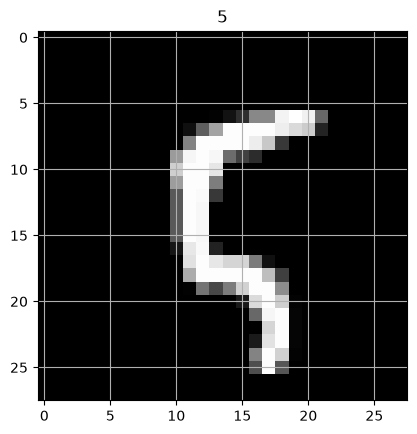

In [443]:
idx = 100
plt.imshow(train_mnist_dataset.data[idx], cmap="gray")
plt.grid(True)
plt.title(train_mnist_dataset.train_labels[idx].item())
plt.show()

In [444]:
for i in dir(nn):
    if i.endswith("_"): continue
    print(i)
nn.MaxPool2d(kernel_size=3)
nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1, stride=1)

AdaptiveAvgPool1d
AdaptiveAvgPool2d
AdaptiveAvgPool3d
AdaptiveLogSoftmaxWithLoss
AdaptiveMaxPool1d
AdaptiveMaxPool2d
AdaptiveMaxPool3d
AlphaDropout
AvgPool1d
AvgPool2d
AvgPool3d
BCELoss
BCEWithLogitsLoss
BatchNorm1d
BatchNorm2d
BatchNorm3d
Bilinear
Buffer
CELU
CTCLoss
ChannelShuffle
CircularPad1d
CircularPad2d
CircularPad3d
ConstantPad1d
ConstantPad2d
ConstantPad3d
Container
Conv1d
Conv2d
Conv3d
ConvTranspose1d
ConvTranspose2d
ConvTranspose3d
CosineEmbeddingLoss
CosineSimilarity
CrossEntropyLoss
CrossMapLRN2d
DataParallel
Dropout
Dropout1d
Dropout2d
Dropout3d
ELU
Embedding
EmbeddingBag
FeatureAlphaDropout
Flatten
Fold
FractionalMaxPool2d
FractionalMaxPool3d
GELU
GLU
GRU
GRUCell
GaussianNLLLoss
GroupNorm
Hardshrink
Hardsigmoid
Hardswish
Hardtanh
HingeEmbeddingLoss
HuberLoss
Identity
InstanceNorm1d
InstanceNorm2d
InstanceNorm3d
KLDivLoss
L1Loss
LPPool1d
LPPool2d
LPPool3d
LSTM
LSTMCell
LayerNorm
LazyBatchNorm1d
LazyBatchNorm2d
LazyBatchNorm3d
LazyConv1d
LazyConv2d
LazyConv3d
LazyConvTrans

Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))

In [445]:
class MnistClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=5, padding=1, stride=1)
        self.max_pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=5, padding=1, stride=1)
        self.fc1 = nn.Linear(5*5*64, 10)
        self.relu = nn.ReLU()


    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.max_pool(x)
        x = self.conv2(x)
        x = self.relu(x)
        x = self.max_pool(x)
        x = x.view(x.size()[0], -1)
        x = self.fc1(x)
        return x

In [446]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)
model = MnistClassifier()
epochs = 10
optimizer = optim.Adam(model.parameters())
train_dataloader = DataLoader(train_mnist_dataset, num_workers=8, persistent_workers=True, batch_size=256)
test_dataloader = DataLoader(test_mnist_dataset, num_workers=8, persistent_workers=True, batch_size=10000)
criterion = nn.CrossEntropyLoss()

cuda


In [447]:
def train(model, epochs, optimizer, train_dataloader, test_dataloader, criterion):
    model = model.to(device)
    # train_dataloader = train_dataloader.to(device)
    # test_dataloader = test_dataloader.to(device)
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for batch_x, batch_y in train_dataloader:
            optimizer.zero_grad()
            batch_x, batch_y = batch_x.to(device, non_blocking=True), batch_y.to(device, non_blocking=True)
            # print(batch_x.shape)
            y_pred = model(batch_x)
            loss = criterion(y_pred, batch_y)
            loss.backward()
            total_loss += loss.item()
            optimizer.step()
        
        loss = total_loss / len(train_dataloader)
        model.eval()
        total_correct = 0
        with torch.no_grad():
            for batch_x, batch_y in test_dataloader:
                batch_x, batch_y = batch_x.to(device, non_blocking=True).float(), batch_y.to(device, non_blocking=True).long()
                # y_pred = nn.Sigmoid()(model(batch_x)).argmax(axis=1)
                y_pred = model(batch_x).argmax(axis=1)
                total_correct += (y_pred == batch_y).sum().item()
            acc = total_correct / test_mnist_dataset.data.shape[0]

            print(f"epoch {epoch}\tloss: {loss:.6f}\tacc: {acc:.3f}")

In [448]:
t1 = time.perf_counter()
train(model, epochs, optimizer, train_dataloader, test_dataloader, criterion)
print(f"Δt: {time.perf_counter()-t1:.2f}s")

epoch 0	loss: 0.317489	acc: 0.973
epoch 1	loss: 0.080209	acc: 0.981
epoch 2	loss: 0.055988	acc: 0.985
epoch 3	loss: 0.044382	acc: 0.984
epoch 4	loss: 0.036836	acc: 0.986
epoch 5	loss: 0.031241	acc: 0.986
epoch 6	loss: 0.027030	acc: 0.987
epoch 7	loss: 0.023263	acc: 0.988
epoch 8	loss: 0.019814	acc: 0.988
epoch 9	loss: 0.016711	acc: 0.988
Δt: 33.75s


In [449]:
for i in dir(model):
    if i.startswith("_"):
        continue
    print(i)
print(type(model))

T_destination
add_module
apply
bfloat16
buffers
call_super_init
children
compile
conv1
conv2
cpu
cuda
double
dump_patches
eval
extra_repr
fc1
float
forward
get_buffer
get_extra_state
get_parameter
get_submodule
half
ipu
load_state_dict
max_pool
modules
mtia
named_buffers
named_children
named_modules
named_parameters
parameters
register_backward_hook
register_buffer
register_forward_hook
register_forward_pre_hook
register_full_backward_hook
register_full_backward_pre_hook
register_load_state_dict_post_hook
register_load_state_dict_pre_hook
register_module
register_parameter
register_state_dict_post_hook
register_state_dict_pre_hook
relu
requires_grad_
set_extra_state
set_submodule
share_memory
state_dict
to
to_empty
train
training
type
xpu
zero_grad
<class '__main__.MnistClassifier'>


In [450]:
batch_x, batch_y = next(iter(train_dataloader))
print(batch_x.shape)
print(batch_y.shape)
print(batch_x[0].shape)
print(batch_x[:,:].mean())
print(batch_x[:,:].max())

torch.Size([256, 1, 28, 28])
torch.Size([256])
torch.Size([1, 28, 28])
tensor(0.1283)
tensor(1.)


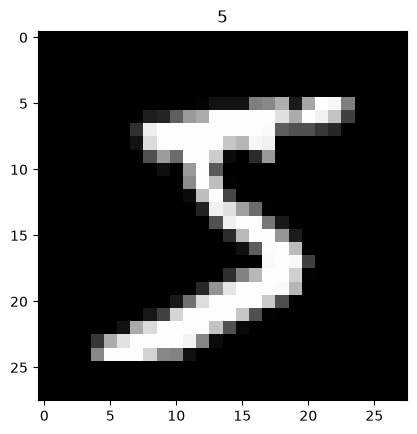

In [451]:
idx = 0
imgs, labels =  next(iter(train_dataloader))
adversarial_img = imgs[idx][0]
label = labels[idx].reshape(1)
plt.imshow(adversarial_img.detach().numpy(), cmap="gray")
plt.title(label.item())
plt.show()

In [452]:
print_dir(adversarial_img)

H
T
_addmm_activation
_autocast_to_full_precision
_autocast_to_reduced_precision
_backward_hooks
_base
_cdata
_clear_non_serializable_cached_data
_conj
_conj_physical
_dimI
_dimV
_fix_weakref
_grad
_grad_fn
_has_symbolic_sizes_strides
_indices
_is_all_true
_is_any_true
_is_view
_is_zerotensor
_lazy_clone
_make_subclass
_make_wrapper_subclass
_neg_view
_nested_tensor_size
_nested_tensor_storage_offsets
_nested_tensor_strides
_nnz
_post_accumulate_grad_hooks
_python_dispatch
_reduce_ex_internal
_rev_view_func_unsafe
_sparse_mask_projection
_to_dense
_to_sparse
_to_sparse_bsc
_to_sparse_bsr
_to_sparse_csc
_to_sparse_csr
_typed_storage
_update_names
_use_count
_values
_version
_view_func
_view_func_unsafe
abs
absolute
acos
acosh
add
addbmm
addcdiv
addcmul
addmm
addmv
addr
adjoint
align_as
align_to
all
allclose
amax
amin
aminmax
angle
any
arccos
arccosh
arcsin
arcsinh
arctan
arctan2
arctanh
argmax
argmin
argsort
argwhere
as_strided
as_strided_scatter
as_subclass
asin
asinh
atan
atan2
atanh


In [453]:
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.functional.cross_entropy

In [ ]:
def fgsm_training(img, model, criterion, optimizer, device, label, learning_rate):
    model.to(device)
    img = img.to(device).reshape(1, 1, 28, 28).detach()
    img.requires_grad_(True)
    label = label.to(device)
    model.eval()

    model.zero_grad()
    optimizer.zero_grad()
    pred = model(img)
    loss = criterion(pred, label)
    loss.backward()
    grad = img.grad.detach()
    x_adv = (img + learning_rate * grad.sign()).clamp(0, 1)
    return x_adv.to("cpu")


In [498]:
img_adv = fgsm_training(adversarial_img, model, criterion, optimizer, device, label, 0.1)

True


tensor(-0.1000, grad_fn=<MinBackward1>) tensor(0.1000, grad_fn=<MaxBackward1>)


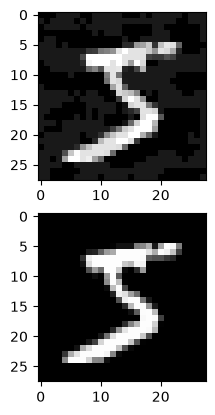

In [499]:
diff = img_adv - adversarial_img
print(diff.min(), diff.max())
_, axis = plt.subplots(2)
axis[0].imshow(img_adv.detach().numpy().reshape(28, 28), cmap="gray")
axis[1].imshow(adversarial_img.detach().numpy(), cmap="gray")
plt.show()

In [ ]:
confidences = nn.Sigmoid()(model(img_adv.to(device)))
pred = confidences.argmax().item()
print(confidences)
print(f"model prediction: {pred}, confidence: {confidences[0,pred].item()}")

tensor([[2.6026e-05, 3.4142e-05, 7.4581e-03, 1.0000e+00, 2.8860e-08, 9.9998e-01,
         1.4267e-09, 5.3582e-03, 2.7076e-02, 8.3372e-01]], device='cuda:0',
       grad_fn=<SigmoidBackward0>)
model prediction: 3, confidence: 0.9999969005584717


: 